In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
sns.set(style="whitegrid")

df = pd.read_csv("../data/raw/Lead Scoring.csv")
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


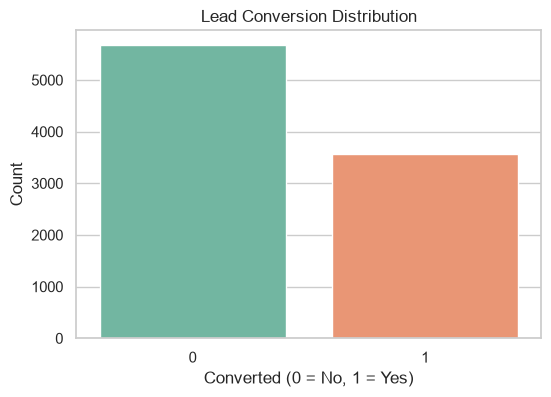

Converted
0    61.461039
1    38.538961
Name: proportion, dtype: float64


In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x='Converted', data=df, palette='Set2')
plt.title("Lead Conversion Distribution")
plt.xlabel("Converted (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

print(df['Converted'].value_counts(normalize=True) * 100)

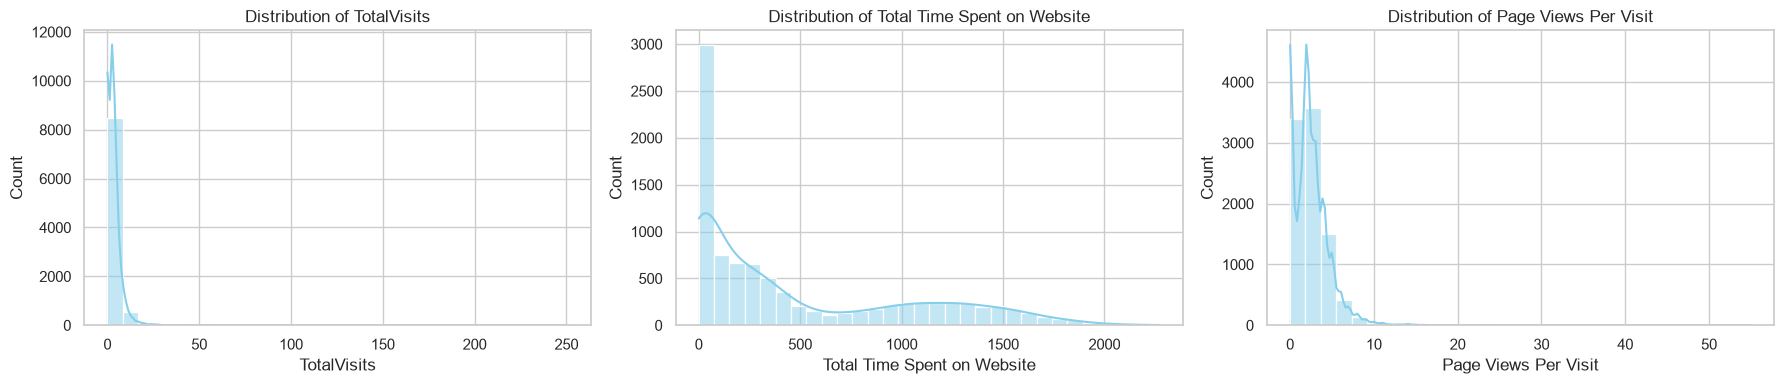

In [5]:
numeric_cols = ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

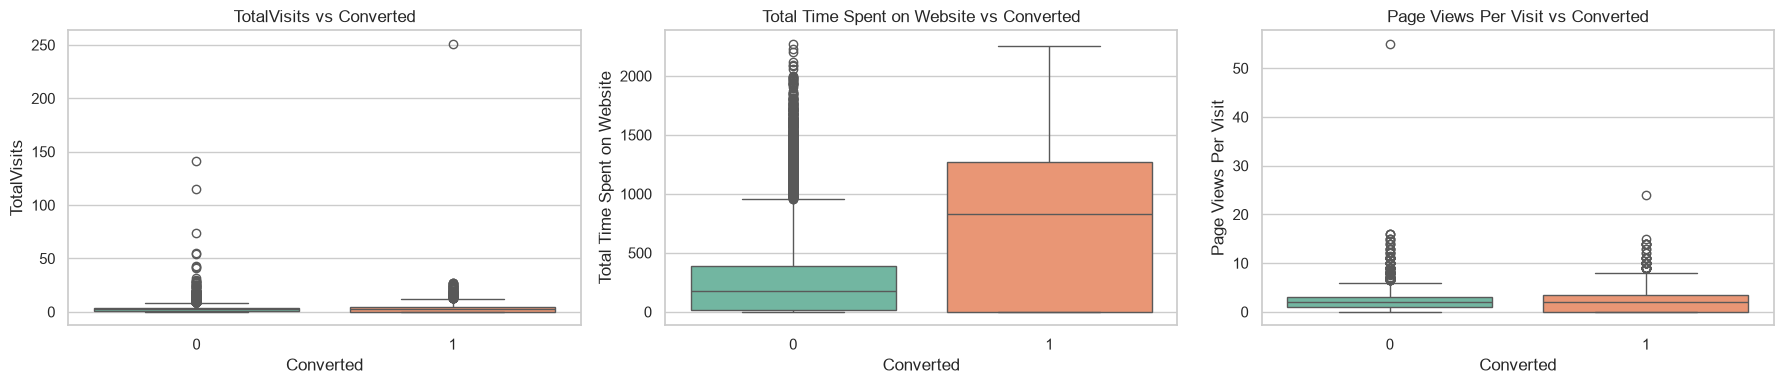

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(x='Converted', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Converted')

plt.tight_layout()
plt.show()

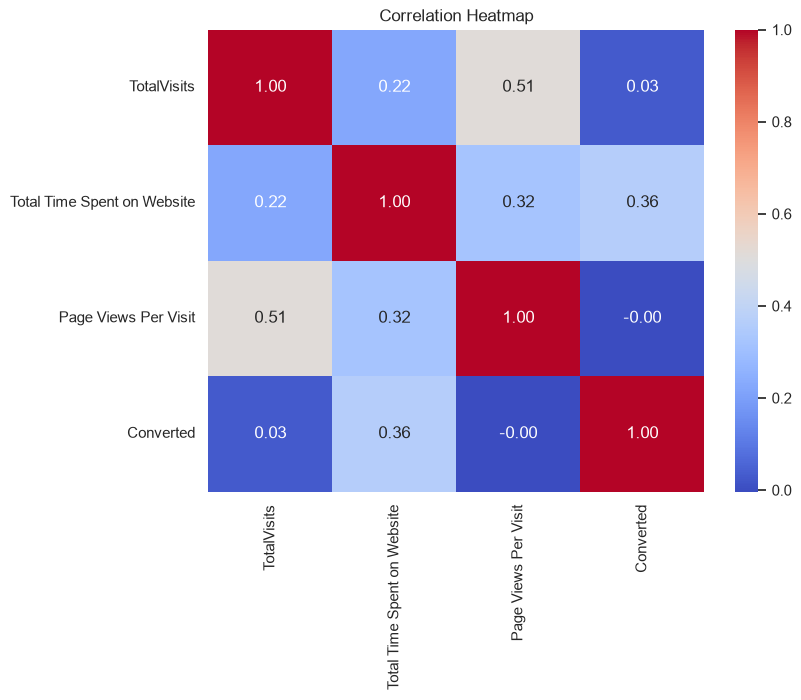

In [7]:
plt.figure(figsize=(8,6))
corr = df[numeric_cols + ['Converted']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

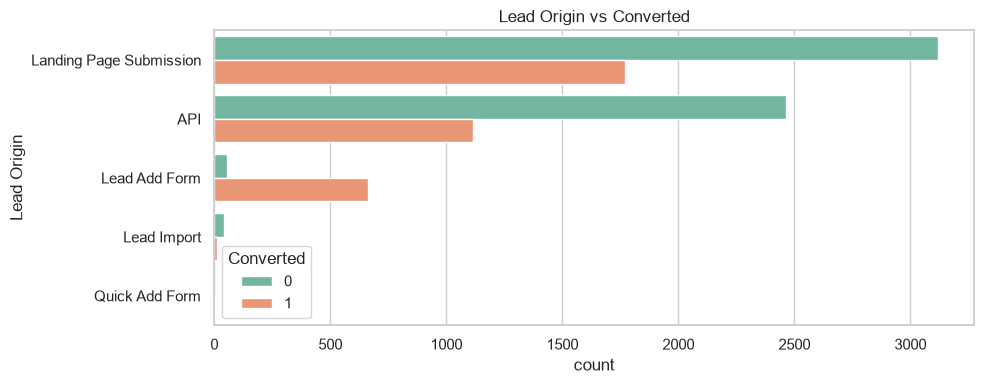

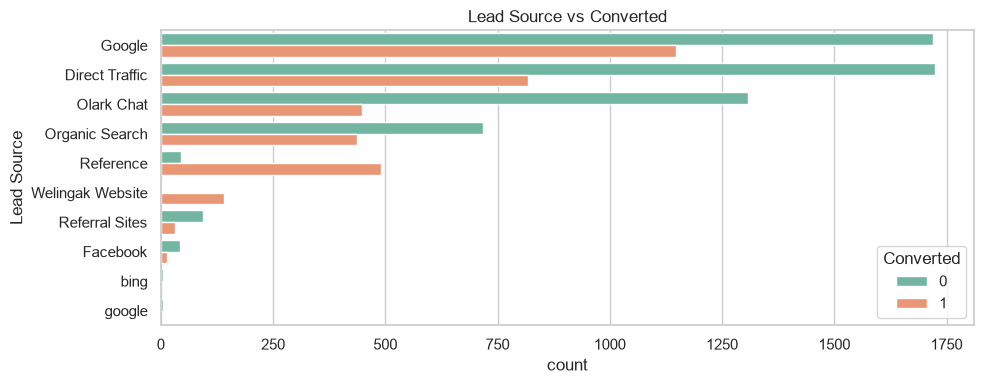

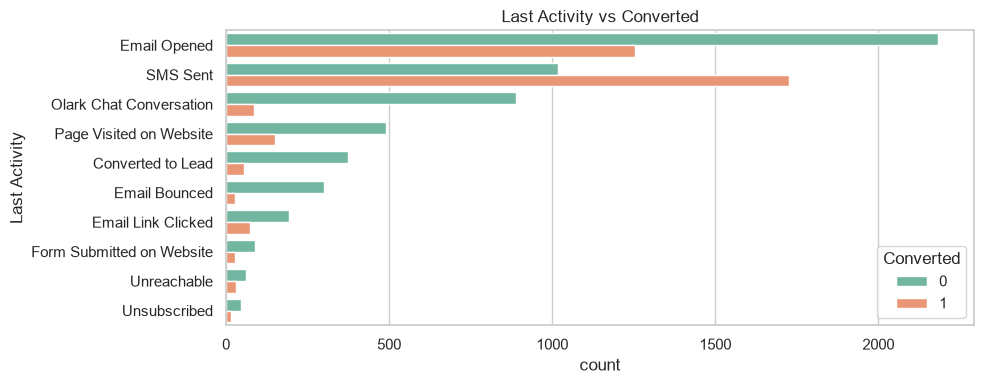

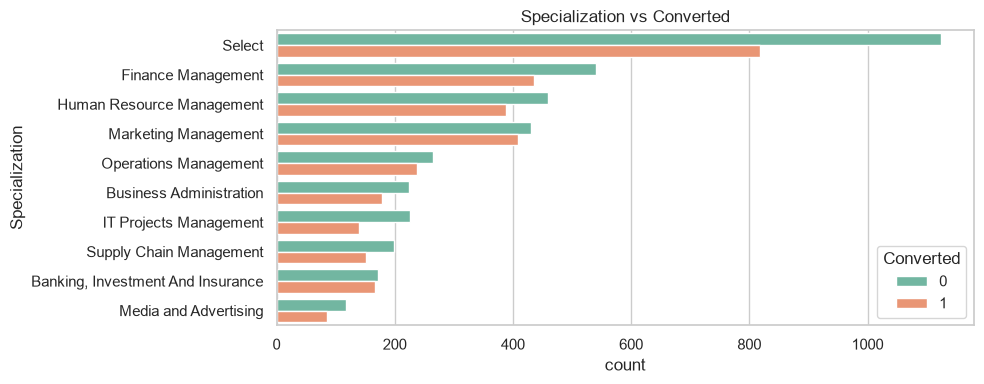

In [8]:
cat_cols = ['Lead Origin', 'Lead Source', 'Last Activity', 'Specialization']

for col in cat_cols:
    plt.figure(figsize=(10,4))
    order = df[col].value_counts().index[:10]  # top 10 categories
    sns.countplot(y=col, hue='Converted', data=df, order=order, palette='Set2')
    plt.title(f'{col} vs Converted')
    plt.tight_layout()
    plt.show()

In [9]:
for col in cat_cols:
    conv_rate = df.groupby(col)['Converted'].mean().sort_values(ascending=False) * 100
    print(f"\n📌 Conversion Rate by {col}:")
    print(conv_rate.head(10))


📌 Conversion Rate by Lead Origin:
Lead Origin
Quick Add Form             100.000000
Lead Add Form               92.479109
Landing Page Submission     36.185018
API                         31.145251
Lead Import                 23.636364
Name: Converted, dtype: float64

📌 Conversion Rate by Lead Source:
Lead Source
Live Chat           100.000000
WeLearn             100.000000
NC_EDM              100.000000
Welingak Website     98.591549
Reference            91.760300
Click2call           75.000000
Social Media         50.000000
Google               39.993026
Organic Search       37.781629
Direct Traffic       32.166732
Name: Converted, dtype: float64

📌 Conversion Rate by Last Activity:
Last Activity
Approached upfront          100.000000
Email Marked Spam           100.000000
Email Received              100.000000
Resubscribed to emails      100.000000
Had a Phone Conversation     73.333333
SMS Sent                     62.914390
Email Opened                 36.456212
Unreachable       